# Sección nueva

In [9]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import logging
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MinMaxScaler,
    LabelEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import (
    PCA,
    FastICA,
)
from sklearn.cluster import KMeans
from sklearn.manifold import(
    MDS,
    TSNE
)
logger = logging.getLogger()
logger.setLevel(logging.ERROR)

In [3]:
df_raw = pd.read_csv('/content/TCGA_data.csv')

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Columns: 20532 entries, Unnamed: 0 to gene_20530
dtypes: float64(20531), object(1)
memory usage: 125.5+ MB


In [8]:
df_raw_labels = pd.read_csv('/content/TCGA_labels.csv')
df_raw_labels

,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA
...,...,...
796,sample_796,BRCA
797,sample_797,LUAD
798,sample_798,COAD
799,sample_799,PRAD


In [4]:
df_baking = df_raw.copy()
df_baking = df_baking.iloc[:,1:]
df = df_baking.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Columns: 20531 entries, gene_0 to gene_20530
dtypes: float64(20531)
memory usage: 125.5 MB


In [5]:
df.sample(10,random_state=2025)

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
509,0.0,2.860148,2.578939,6.501149,9.785286,0.0,6.751437,0.699729,0.0,0.0,...,5.899096,8.780792,10.203996,5.821598,9.905653,11.773296,10.018478,9.552070,5.914108,0.000000
91,0.0,3.801966,3.459130,5.997184,9.710472,0.0,8.905616,0.554147,0.0,0.0,...,5.477337,8.329877,9.821407,5.801886,9.755719,11.027975,9.899875,9.385343,4.401617,0.000000
109,0.0,5.409476,5.161098,7.298576,9.739624,0.0,8.067278,0.944559,0.0,0.0,...,6.117352,9.074519,9.752826,7.745452,10.091025,10.825873,10.392854,9.188648,2.605376,3.848728
400,0.0,3.925658,3.656496,7.934086,10.364748,0.0,8.405418,1.719797,0.0,0.0,...,6.871955,9.871773,10.142694,0.895458,8.662850,12.462799,9.886270,8.642290,1.102322,0.000000
182,0.0,3.495324,2.079702,6.853160,9.971227,0.0,7.286567,0.000000,0.0,0.0,...,5.745022,9.040638,10.105607,7.644585,10.034510,11.826104,10.299620,10.244685,6.008229,0.000000
375,0.0,1.148804,1.986375,6.662604,9.997772,0.0,8.524714,0.606442,0.0,0.0,...,5.083869,8.385142,9.765508,7.366794,8.739214,12.495810,9.915091,8.992542,4.189145,0.000000
391,0.0,4.094565,4.704501,7.545559,9.752299,0.0,8.595821,0.859970,0.0,0.0,...,4.598568,7.654557,10.089887,7.107677,8.832156,12.816038,9.317229,9.461801,9.258929,0.000000
621,0.0,3.213441,3.175557,6.655727,10.182481,0.0,9.028144,0.515208,0.0,0.0,...,5.512227,9.134437,9.962423,7.098727,9.297820,12.126246,9.385610,9.640391,7.502052,0.000000
669,0.0,2.603668,1.555865,6.258110,9.474446,0.0,6.307525,0.000000,0.0,0.0,...,6.048129,8.286867,9.507612,0.000000,9.925629,12.364091,9.852411,9.482556,5.173611,0.000000
710,0.0,3.229880,2.798901,8.031544,8.674496,0.0,9.380128,0.000000,0.0,0.0,...,5.158672,8.182201,10.488453,8.180327,9.139736,12.186442,9.660670,9.628703,2.815227,0.000000


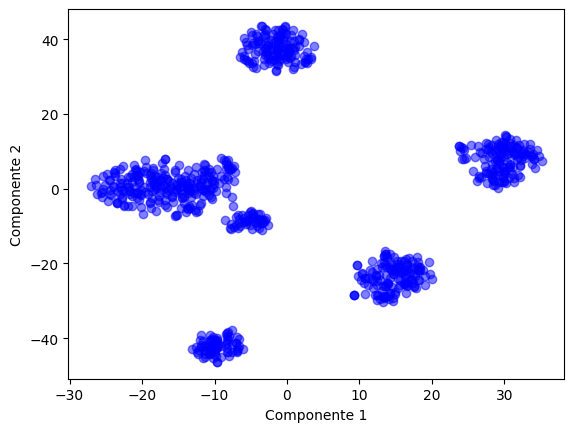

In [6]:
tsne_= TSNE(n_components=2,random_state=2025)
X_tsne = tsne_.fit_transform(df)
plt.scatter(X_tsne[:,0],X_tsne[:,1],color='blue',alpha=0.5)
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()

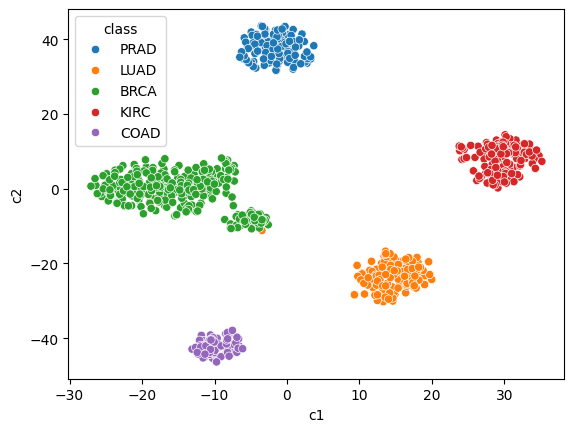

In [11]:
df_cancer = pd.DataFrame(X_tsne,columns=['c1','c2'])
df_cancer['class']=df_raw_labels['Class']
sns.scatterplot(data=df_cancer,x='c1',y='c2',hue='class')
plt.show()